# Strain comparison: EGC, FBA, pFBA, FVA and subsystem analyses

Analyses:

- Erroneous energy-generating cycles (EGCs) — confirm absence (Fritzemeier et al. 2017)
- Flux variation across strains and carbon sources using pFBA and FVA
- Accessory-reaction flux activity; GAM/NGAM sensitivity
- Metabolic costs, FVA flux ranges, subsystem activity profiles

Models are loaded from `model/pAo_strain-GEMs_validated.pickle` and filtered to the 8
target *Aspergillus oryzae* strains. All simulations use a carbon-limiting minimal medium
with one of four carbon sources: glucose, glycerol, maltose, or xylose.

> **Canonical analysis & methodology.** The up-to-date analysis is `run_p5_analysis.py`, which uses **carbon-normalised uptake** (equal C-mol across substrates), an imposed **non-growth ATP maintenance** (NGAM = 1 mmol ATP/gDW/h; GAM = 49 mmol ATP/gDW), and **loopless** flux variability analysis. The current results and figures are in **Section 9** below.
>
> Sections 1?8 are the original exploratory cells and use the earlier conventions (equal-mmol uptake, NGAM = 0, standard FVA); rerun `run_p5_analysis.py` to regenerate every CSV and figure consistently.

## 0. Setup

In [ ]:
import os
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cobra
from cobra import Reaction, Metabolite
from cobra.flux_analysis import pfba, flux_variability_analysis
from pickle import load

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

In [ ]:
TARGET_STRAINS = [
    'Aspergillus_oryzae_RIB40_GCF_000184455.2',
    'Aspergillus_oryzae_NRRL_2217',
    'Aspergillus_oryzae_NRRL_3483_GCA_034767915.1',
    'Aspergillus_oryzae_NRRL_3488',
    'Aspergillus_oryzae_NRRL_5589',
    'Aspergillus_oryzae_NRRL_5592_GCA_034767935.1',
    'Aspergillus_oryzae_NRRL_35890_GCA_034767955.1',
    'Aspergillus_oryzae_NRRL_471',
]

STRAIN_SHORT = {
    'Aspergillus_oryzae_RIB40_GCF_000184455.2':     'RIB40',
    'Aspergillus_oryzae_NRRL_2217':                  'NRRL_2217',
    'Aspergillus_oryzae_NRRL_3483_GCA_034767915.1':  'NRRL_3483',
    'Aspergillus_oryzae_NRRL_3488':                  'NRRL_3488',
    'Aspergillus_oryzae_NRRL_5589':                  'NRRL_5589',
    'Aspergillus_oryzae_NRRL_5592_GCA_034767935.1':  'NRRL_5592',
    'Aspergillus_oryzae_NRRL_35890_GCA_034767955.1': 'NRRL_35890',
    'Aspergillus_oryzae_NRRL_471':                   'NRRL_471',
}

CARBON_SOURCES = {
    'Glucose':  'C00031[e]',
    'Glycerol': 'C00116[e]',
    'Maltose':  'C00208[e]',
    'Xylose':   'C00181[e]',
}

BIOMASS_RXN        = 'r2359'
NGAM_RXN           = 'r1901'
OUT_DIR            = '../data/intermediate'
CARBON_UPTAKE_RATE = 10.0   # mmol/gDW/h, standard minimal-medium constraint

In [ ]:
with open('../model/pAo_strain-GEMs_validated.pickle', 'rb') as f:
    all_models = load(f)

models = {m.id: m for m in all_models if m.id in TARGET_STRAINS}
print(f'Loaded {len(models)} / {len(TARGET_STRAINS)} target strain models')
for sid in TARGET_STRAINS:
    status = 'OK' if sid in models else 'MISSING'
    print(f'  [{status}] {STRAIN_SHORT[sid]}')

# Set biomass as default objective for all models.
# The pickle saves r1901 (ATP) as objective; we need r2359 (biomass) for growth analyses.
for model in models.values():
    model.objective = model.reactions.get_by_id(BIOMASS_RXN)

# Gapfill r766 (5-proFAR isomerase, histidine biosynthesis) for NRRL_35890.
# This fix was applied in p3 to the Medusa ensemble but was not propagated to the 187-strain pickle.
_NRRL35890 = 'Aspergillus_oryzae_NRRL_35890_GCA_034767955.1'
if _NRRL35890 in models:
    m35 = models[_NRRL35890]
    if 'r766' not in {r.id for r in m35.reactions}:
        _ref = next(m for sid, m in models.items()
                    if sid != _NRRL35890 and 'r766' in {r.id for r in m.reactions})
        _ref_rxn = _ref.reactions.get_by_id('r766')
        _new_rxn = Reaction('r766', name=_ref_rxn.name,
                            lower_bound=_ref_rxn.lower_bound, upper_bound=_ref_rxn.upper_bound)
        _new_rxn.subsystem = _ref_rxn.subsystem
        m35.add_reactions([_new_rxn])
        _m35_met_ids = {m.id for m in m35.metabolites}
        _met_dict = {}
        for _met, _coef in _ref_rxn.metabolites.items():
            if _met.id in _m35_met_ids:
                _met_dict[m35.metabolites.get_by_id(_met.id)] = _coef
            else:
                _new_met = Metabolite(id=_met.id, name=_met.name,
                                     formula=_met.formula, compartment=_met.compartment)
                m35.add_metabolites([_new_met])
                _met_dict[_new_met] = _coef
        _new_rxn.add_metabolites(_met_dict)
        print('  Applied r766 gapfill for NRRL_35890 (histidine biosynthesis)')

In [ ]:
def setup_carbon_medium(model, carbon_met_id):
    """Add uptake exchange for the target carbon source. Call inside `with model:` block."""
    met_ids = {m.id for m in model.metabolites}
    if carbon_met_id in met_ids:
        model.add_boundary(
            model.metabolites.get_by_id(carbon_met_id),
            type='exchange', lb=-CARBON_UPTAKE_RATE, ub=1000
        )
    else:
        print(f'  Warning: {carbon_met_id} not in {model.id}')

## 1. EGC detection

Method: Fritzemeier et al. (2017) PLOS Comput Biol. Close all nutrient uptake, then for each
energy carrier add a dissipation reaction and maximise its flux. A flux > 0 indicates an
erroneous energy-generating cycle (EGC).

Adapted from existing code in `p3_simulations_extra.ipynb`. Extended to the full 12-carrier
list from Fritzemeier et al. (ubiquinol-8 and 2-demethylmenaquinol are bacterial and likely
absent; NaN is reported when metabolites are not in the model).

In [ ]:
DISSIPATION_SPECS = {
    'ATP':         {'C00002[c]': -1, 'C00001[c]': -1, 'C00008[c]': 1, 'C00009[c]': 1, 'C00080[c]': 1},
    'CTP':         {'C00063[c]': -1, 'C00001[c]': -1, 'C00112[c]': 1, 'C00009[c]': 1, 'C00080[c]': 1},
    'GTP':         {'C00044[c]': -1, 'C00001[c]': -1, 'C00035[c]': 1, 'C00009[c]': 1, 'C00080[c]': 1},
    'UTP':         {'C00075[c]': -1, 'C00001[c]': -1, 'C00015[c]': 1, 'C00009[c]': 1, 'C00080[c]': 1},
    'ITP':         {'C00081[c]': -1, 'C00001[c]': -1, 'C00104[c]': 1, 'C00009[c]': 1, 'C00080[c]': 1},
    'NADH':        {'C00004[c]': -1, 'C00003[c]': 1,  'C00080[c]': 1},
    'NADPH':       {'C00005[c]': -1, 'C00006[c]': 1,  'C00080[c]': 1},
    'FADH2':       {'C01352[m]': -1, 'C00016[m]': 1,  'C00080[m]': 2},
    'FMNH2':       {'C01847[c]': -1, 'C00061[c]': 1,  'C00080[c]': 2},
    'AcetylCoA':   {'C00024[c]': -1, 'C00001[c]': -1, 'C00010[c]': 1, 'C00033[c]': 1},
    'L-Glutamate': {'C00025[c]': -1, 'C00026[c]': 1,  'C00014[c]': 1},
    'Ubiquinol8':  {'C00390[m]': -1, 'C00399[m]': 1,  'C00080[m]': 2},
}


def test_egc(model, specs=DISSIPATION_SPECS, tol=1e-6):
    """Return dict of energy carrier -> max dissipation flux with all uptake closed.
    NaN = one or more metabolites absent from this model."""
    met_ids = {m.id for m in model.metabolites}
    results = {}
    with model:
        model.medium = {r_id: 0.0 for r_id in model.medium}
        for name, stoich in specs.items():
            missing = [mid for mid in stoich if mid not in met_ids]
            if missing:
                results[name] = float('nan')
                continue
            with model:
                diss = Reaction(f'DISS_{name}', lower_bound=0.0, upper_bound=1000.0)
                model.add_reactions([diss])
                diss.add_metabolites(
                    {model.metabolites.get_by_id(mid): c for mid, c in stoich.items()})
                model.objective = diss
                sol = model.optimize()
                flux = sol.objective_value if sol.status == 'optimal' else 0.0
                results[name] = flux
                if flux > tol:
                    active = [r.id for r in model.reactions
                              if r.id != diss.id and abs(sol.fluxes.get(r.id, 0)) > tol]
                    print(f'  EGC [{name}] in {model.id}: flux={flux:.4f}')
                    print(f'    Active reactions: {active[:20]}')
    return results

In [ ]:
print('Testing EGCs across all strain models...')
egc_rows = []
for strain_id, model in models.items():
    print(f'  {STRAIN_SHORT[strain_id]}', end=' ')
    row = test_egc(model)
    row['model'] = STRAIN_SHORT[strain_id]
    egc_rows.append(row)
    print('done')

egc_df = pd.DataFrame(egc_rows).set_index('model')

numeric_cols = egc_df.select_dtypes(include='number')
max_flux = numeric_cols.max().max()
print(f'\nMax dissipation flux across all models and carriers: {max_flux:.2e}')
if max_flux < 1e-6:
    print('Result: NO erroneous energy-generating cycles detected.')
else:
    print('Result: EGCs detected — see rows/columns with flux > 0 above.')

In [ ]:
egc_df

## 2. FBA growth predictions

Standard FBA maximising biomass (r2359) on four carbon sources. Growth rates are compared
with wet-lab BioLog data to demonstrate that FBA cannot reproduce the observed strain
differences.

In [ ]:
fba_rows = []
for strain_id, model in models.items():
    for cs_name, cs_met in CARBON_SOURCES.items():
        with model:
            setup_carbon_medium(model, cs_met)
            model.objective = model.reactions.get_by_id(BIOMASS_RXN)
            sol = model.optimize()
            growth = sol.objective_value if sol.status == 'optimal' else 0.0
            o2 = sol.fluxes.get('r2202', float('nan')) if sol.status == 'optimal' else float('nan')
        fba_rows.append({
            'strain': strain_id,
            'strain_short': STRAIN_SHORT[strain_id],
            'carbon_source': cs_name,
            'growth_rate': growth,
            'o2_flux': o2,
        })

growth_df = pd.DataFrame(fba_rows)
pivot_growth = growth_df.pivot(index='strain_short', columns='carbon_source', values='growth_rate')
print('FBA growth rates (h\u207b\u00b9):')
print(pivot_growth.to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot_growth[['Glucose', 'Glycerol', 'Maltose', 'Xylose']],
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_title('FBA growth rates (h\u207b\u00b9) \u2014 8 strains \xd7 4 carbon sources')
ax.set_xlabel('Carbon source')
ax.set_ylabel('Strain')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig_FBA_growth_heatmap.svg')
plt.show()

In [ ]:
# Load wet-lab BioLog data for comparison
biolog = pd.read_csv('../data/biolog/PM_all.csv', sep=';')
print('BioLog shape:', biolog.shape)
print('Columns:', biolog.columns.tolist())
biolog.head(3)

In [ ]:
# Compute consensus growth per (strain, carbon source) across replicates
cs_map = {'D_Glucose': 'Glucose', 'Glycerol': 'Glycerol', 'D_Maltose': 'Maltose', 'D_Xylose': 'Xylose'}
pm_sub = biolog[biolog['Medium'].isin(cs_map) & biolog['Isolate'].isin(STRAIN_SHORT.values())].copy()
pm_sub['carbon_source'] = pm_sub['Medium'].map(cs_map)

def _frac_true(series):
    n_true  = (series == True).sum()   # noqa: E712
    n_false = (series == False).sum()  # noqa: E712
    total = n_true + n_false
    return n_true / total if total > 0 else float('nan')

biolog_consensus = (
    pm_sub.groupby(['Isolate', 'carbon_source'])['Observed']
    .apply(_frac_true)
    .reset_index(name='frac_true')
)
biolog_pivot = biolog_consensus.pivot(index='Isolate', columns='carbon_source', values='frac_true')
biolog_ordered = biolog_pivot.reindex(
    index=sorted(STRAIN_SHORT.values()),
    columns=['Glucose', 'Glycerol', 'Maltose', 'Xylose']
)
print('BioLog consensus growth (fraction of replicates with positive growth):')
biolog_ordered

## 3. pFBA metabolic costs

Parsimonious FBA minimises total absolute flux at optimal growth. Total flux is a proxy for
metabolic cost (enzyme burden). Differences between strains on the same substrate reveal
routing differences even when growth rates are identical.

In [ ]:
pfba_rows = []
for strain_id, model in models.items():
    for cs_name, cs_met in CARBON_SOURCES.items():
        with model:
            setup_carbon_medium(model, cs_met)
            try:
                sol = pfba(model)
                total_flux = sol.fluxes.abs().sum()
                growth = sol.fluxes.get(BIOMASS_RXN, 0.0)
                status = sol.status
            except Exception as e:
                print(f'  pFBA failed {STRAIN_SHORT[strain_id]}/{cs_name}: {e}')
                total_flux, growth, status = float('nan'), float('nan'), 'failed'
        pfba_rows.append({
            'strain': strain_id,
            'strain_short': STRAIN_SHORT[strain_id],
            'carbon_source': cs_name,
            'total_flux': total_flux,
            'growth_rate': growth,
            'status': status,
        })

pfba_df = pd.DataFrame(pfba_rows)
pivot_pflux = pfba_df.pivot(index='strain_short', columns='carbon_source', values='total_flux')
print('pFBA total flux (mmol/gDW/h):')
print(pivot_pflux.to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    pivot_pflux[['Glucose', 'Glycerol', 'Maltose', 'Xylose']],
    annot=True, fmt='.0f', cmap='Blues',
    linewidths=0.5, linecolor='gray', ax=axes[0]
)
axes[0].set_title('pFBA total flux (mmol/gDW/h)')
axes[0].set_xlabel('Carbon source')
axes[0].set_ylabel('Strain')

pivot_pgrowth = pfba_df.pivot(index='strain_short', columns='carbon_source', values='growth_rate')
sns.heatmap(
    pivot_pgrowth[['Glucose', 'Glycerol', 'Maltose', 'Xylose']],
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, linecolor='gray', ax=axes[1]
)
axes[1].set_title('pFBA growth rate (h\u207b\u00b9)')
axes[1].set_xlabel('Carbon source')
axes[1].set_ylabel('Strain')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig_pFBA_metabolic_cost.svg')
plt.show()

## 4. FVA flux variability

Flux variability analysis at 90% optimal growth reveals which reactions have alternative
routes (range > 0) and which are fixed. Reactions with large inter-strain variance in flux
range are candidate mechanistic differentiators between strains.

**Note**: FVA runs \~2 LP solves per reaction per strain/substrate combination. With 8 strains
and 4 substrates this is \~32 FVA instances. Allow several minutes.

In [ ]:
fva_data = {}
for strain_id, model in models.items():
    fva_data[strain_id] = {}
    for cs_name, cs_met in CARBON_SOURCES.items():
        with model:
            setup_carbon_medium(model, cs_met)
            sol = model.optimize()
            if sol.status != 'optimal' or sol.objective_value < 1e-6:
                print(f'  Skipping FVA {STRAIN_SHORT[strain_id]}/{cs_name}: no growth')
                continue
            print(f'  FVA {STRAIN_SHORT[strain_id]}/{cs_name} (growth={sol.objective_value:.4f})...')
            fva = flux_variability_analysis(model, fraction_of_optimum=0.9, processes=1)
            fva['range'] = fva['maximum'] - fva['minimum']
            fva_data[strain_id][cs_name] = fva

print('FVA complete.')

In [ ]:
fva_rows = []
for strain_id, cs_dict in fva_data.items():
    for cs_name, fva in cs_dict.items():
        tmp = fva.copy()
        tmp['strain'] = strain_id
        tmp['strain_short'] = STRAIN_SHORT[strain_id]
        tmp['carbon_source'] = cs_name
        tmp.index.name = 'reaction'
        fva_rows.append(tmp.reset_index())

fva_long = pd.concat(fva_rows, ignore_index=True) if fva_rows else pd.DataFrame()
print(f'FVA entries: {len(fva_long)}')

In [ ]:
if fva_long.empty:
    print('No FVA data available.')
else:
    for cs_name in CARBON_SOURCES:
        subset = fva_long[fva_long['carbon_source'] == cs_name]
        if subset.empty:
            continue
        inter_strain_var = subset.groupby('reaction')['range'].var().dropna().sort_values(ascending=False)
        top_rxns = inter_strain_var.head(30).index.tolist()

        plot_data = subset[subset['reaction'].isin(top_rxns)].pivot(
            index='reaction', columns='strain_short', values='range').fillna(0)

        if plot_data.empty:
            continue

        fig, ax = plt.subplots(figsize=(12, 8))
        sns.heatmap(plot_data, cmap='viridis', ax=ax, yticklabels=True,
                    linewidths=0.2, linecolor='lightgray')
        ax.set_title(f'FVA flux range (90% optimum) \u2014 {cs_name}\nTop 30 reactions by inter-strain variance')
        ax.set_xlabel('Strain')
        ax.set_ylabel('Reaction')
        plt.tight_layout()
        plt.savefig(f'{OUT_DIR}/fig_FVA_{cs_name}.svg')
        plt.show()

## 5. Accessory reaction analysis

Reactions present in \u22651 but <8 strains are "accessory". We check which of these carry
flux (range > 0 in FVA) on at least one carbon source, i.e., are functionally relevant.

In [ ]:
all_rxn_ids = set()
for m in models.values():
    all_rxn_ids.update(r.id for r in m.reactions)

presence = pd.DataFrame(
    {STRAIN_SHORT[sid]: {r.id: 1 for r in m.reactions} for sid, m in models.items()},
    index=sorted(all_rxn_ids)
).fillna(0).astype(int)

n_strains = len(models)
rxn_counts = presence.sum(axis=1)
core_rxns      = rxn_counts[rxn_counts == n_strains].index.tolist()
accessory_rxns = rxn_counts[(rxn_counts > 0) & (rxn_counts < n_strains)].index.tolist()
print(f'Core reactions (all {n_strains} strains): {len(core_rxns)}')
print(f'Accessory reactions (1\u2013{n_strains-1} strains): {len(accessory_rxns)}')

In [ ]:
if fva_long.empty:
    print('FVA data not available; run Section 4 first.')
    acc_summary = pd.DataFrame()
else:
    # Build reaction annotation from loaded models
    rxn_info = {}
    for m in models.values():
        for r in m.reactions:
            if r.id not in rxn_info:
                rxn_info[r.id] = {'name': r.name, 'subsystem': r.subsystem}

    acc_fva = fva_long[fva_long['reaction'].isin(accessory_rxns)].copy()
    active_acc = acc_fva[acc_fva['range'] > 1e-6]

    acc_summary = (
        active_acc
        .groupby(['reaction', 'carbon_source'])
        .agg(n_active_strains=('strain', 'nunique'), max_range=('range', 'max'))
        .reset_index()
    )
    acc_summary['n_strains_present'] = acc_summary['reaction'].map(rxn_counts)
    acc_summary['name']      = acc_summary['reaction'].map(lambda x: rxn_info.get(x, {}).get('name', ''))
    acc_summary['subsystem'] = acc_summary['reaction'].map(lambda x: rxn_info.get(x, {}).get('subsystem', ''))

    print(f'Flux-active accessory reactions: {acc_summary["reaction"].nunique()}')
    display(acc_summary.sort_values(['n_strains_present', 'reaction']).head(50))

## 6. GAM/NGAM sensitivity

**GAM** (growth-associated maintenance) is the ATP cost per unit biomass, encoded in the
biomass reaction (r2359) stoichiometry.

**NGAM** (non-growth-associated maintenance) is the minimum ATP hydrolysis flux, set as the
lower bound of r1901. A sensitivity sweep shows how growth rate depends on NGAM.

In [ ]:
ref_model = models[TARGET_STRAINS[0]]
biomass_rxn = ref_model.reactions.get_by_id(BIOMASS_RXN)
ngam_rxn    = ref_model.reactions.get_by_id(NGAM_RXN)

atp_id = 'C00002[c]'
atp_met_ids = {m.id for m in ref_model.metabolites}
if atp_id in atp_met_ids:
    atp_met = ref_model.metabolites.get_by_id(atp_id)
    gam = biomass_rxn.metabolites.get(atp_met, None)
    print(f'GAM (ATP stoichiometry in {BIOMASS_RXN}): {gam} mmol/gDW')
    print(f'  (negative = consumed by biomass synthesis)')
    print(f'  Literature: A. oryzae iWV1314 ~59 mmol/gDW; A. niger ~64 mmol/gDW')
else:
    print(f'ATP metabolite {atp_id} not found.')

print(f'\nNGAM reaction {NGAM_RXN}: lb={ngam_rxn.lower_bound}, ub={ngam_rxn.upper_bound} mmol/gDW/h')
print(f'  Reaction: {ngam_rxn.reaction}')

In [ ]:
ngam_sweep_rows = []
current_ngam_lb = ngam_rxn.lower_bound

for ngam in np.linspace(0, 10, 21):
    for cs_name, cs_met in CARBON_SOURCES.items():
        with ref_model:
            setup_carbon_medium(ref_model, cs_met)
            ref_model.objective = ref_model.reactions.get_by_id(BIOMASS_RXN)
            ref_model.reactions.get_by_id(NGAM_RXN).lower_bound = ngam
            sol = ref_model.optimize()
            growth = sol.objective_value if sol.status == 'optimal' else 0.0
        ngam_sweep_rows.append({'ngam': ngam, 'carbon_source': cs_name, 'growth_rate': growth})

ngam_df = pd.DataFrame(ngam_sweep_rows)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('tab10', n_colors=4)
for (cs_name, grp), color in zip(ngam_df.groupby('carbon_source'), colors):
    ax.plot(grp['ngam'], grp['growth_rate'], label=cs_name, color=color, marker='o', markersize=4)
ax.axvline(x=current_ngam_lb, color='gray', linestyle='--',
           label=f'Current NGAM lb = {current_ngam_lb}')
ax.set_xlabel('NGAM (mmol ATP/gDW/h)')
ax.set_ylabel('Growth rate (h\u207b\u00b9)')
ax.set_title(f'Growth rate vs NGAM \u2014 {STRAIN_SHORT[TARGET_STRAINS[0]]}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig_NGAM_sensitivity.svg')
plt.show()

## 7. Subsystem activity profiles

pFBA fluxes are grouped by reaction subsystem. The fraction of total absolute flux in each
subsystem measures its activity. Subsystems with >0.5% activity share in at least one
condition are shown.

Subsystem labels are read from the `.subsystem` attribute, which is preserved in pickle files
but may be lost in SBML/XML export.

In [ ]:
print('Computing subsystem activity from pFBA (re-running pFBA)...')
sub_rows = []
for strain_id, model in models.items():
    for cs_name, cs_met in CARBON_SOURCES.items():
        with model:
            setup_carbon_medium(model, cs_met)
            try:
                sol = pfba(model)
            except Exception as e:
                print(f'  pFBA failed {STRAIN_SHORT[strain_id]}/{cs_name}: {e}')
                continue
            for rxn in model.reactions:
                flux = abs(sol.fluxes.get(rxn.id, 0))
                if flux < 1e-9:
                    continue
                sub_rows.append({
                    'strain': strain_id,
                    'strain_short': STRAIN_SHORT[strain_id],
                    'carbon_source': cs_name,
                    'reaction': rxn.id,
                    'subsystem': rxn.subsystem if rxn.subsystem else 'Unknown',
                    'abs_flux': flux,
                })

sub_df = pd.DataFrame(sub_rows)
print(f'Non-zero flux entries: {len(sub_df)}')

In [ ]:
sub_agg = (
    sub_df
    .groupby(['strain_short', 'carbon_source', 'subsystem'])['abs_flux']
    .sum()
    .reset_index()
)
total_by_cond = (
    sub_df
    .groupby(['strain_short', 'carbon_source'])['abs_flux']
    .sum()
    .rename('total_flux')
    .reset_index()
)
sub_agg = sub_agg.merge(total_by_cond, on=['strain_short', 'carbon_source'])
sub_agg['fraction'] = sub_agg['abs_flux'] / sub_agg['total_flux']

max_frac_per_sub = sub_agg.groupby('subsystem')['fraction'].max()
active_subsystems = max_frac_per_sub[max_frac_per_sub > 0.005].sort_values(ascending=False).index.tolist()
print(f'Active subsystems (>0.5% in \u22651 condition): {len(active_subsystems)}')

In [ ]:
for cs_name in CARBON_SOURCES:
    sub_cs = sub_agg[
        (sub_agg['carbon_source'] == cs_name) &
        (sub_agg['subsystem'].isin(active_subsystems))
    ]
    if sub_cs.empty:
        continue
    pivot_sub = sub_cs.pivot(
        index='subsystem', columns='strain_short', values='fraction'
    ).reindex(index=active_subsystems).fillna(0)

    fig_h = max(5, len(active_subsystems) * 0.28)
    fig, ax = plt.subplots(figsize=(10, fig_h))
    sns.heatmap(
        pivot_sub, cmap='RdYlBu_r', ax=ax,
        linewidths=0.2, linecolor='lightgray',
        vmin=0, vmax=pivot_sub.values.max()
    )
    ax.set_title(f'Subsystem activity fraction \u2014 {cs_name}')
    ax.set_xlabel('Strain')
    ax.set_ylabel('Subsystem')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/fig_subsystem_{cs_name}.svg')
    plt.show()

## 8. Export

In [ ]:
os.makedirs(OUT_DIR, exist_ok=True)

exports = [
    (egc_df,     f'{OUT_DIR}/strain_comparison_EGC.csv',         True),
    (growth_df,  f'{OUT_DIR}/strain_comparison_FBA.csv',         False),
    (pfba_df,    f'{OUT_DIR}/strain_comparison_pFBA.csv',        False),
    (fva_long,   f'{OUT_DIR}/strain_comparison_FVA.csv',         False),
    (sub_agg,    f'{OUT_DIR}/strain_comparison_subsystems.csv',  False),
    (ngam_df,    f'{OUT_DIR}/strain_comparison_NGAM.csv',        False),
]

try:
    exports.append((acc_summary, f'{OUT_DIR}/strain_comparison_accessory.csv', False))
except NameError:
    pass

for df, path, use_index in exports:
    if df is not None and not df.empty:
        df.to_csv(path, index=use_index)
        print(f'  Saved: {path}')
    else:
        print(f'  Skipped (empty): {path}')

## 9. Figures

Two figures are produced by `run_p5_analysis.py` from the CSVs in `data/intermediate/`: the four-panel manuscript figure and the supplementary all-reaction loopless-FVA heatmap. Methodological choices: carbon sources fed at **equal C-mol** supply, non-growth ATP maintenance (**NGAM**) imposed, and flux variability analysis run **loopless** so reported ranges are thermodynamically attainable.

In [ ]:
import pandas as pd, numpy as np
from IPython.display import Image, display
OUT='../data/intermediate/'
print('Loaded')

Loaded


### 9a. Manuscript figure

The proposed manuscript figure (`fig_mechanistic_manuscript`), styled to match Figure 5 (ggplot aesthetic, shared strain colours), shows that the strain models do not differ appreciably in the solution space probed by the tested growth conditions: **(A)** FBA predicts a near-identical maximum growth rate for every strain on each carbon source (strain CV < 0.1%), in direct contrast to the experimental variation in Figure 5; **(B)** the parsimonious (pFBA) optimum is set by the carbon source, not the strain (strain CV < 0.3%); **(C)** single-reaction deletion — 169 essential core reactions vs 0/634 accessory deletions affecting growth, so the accessory genome is dispensable for the optimum; **(D)** substrate-specific subsystem rewiring with the 8 strains overlapping tightly (max inter-strain SD ≈ 3 percentage points).

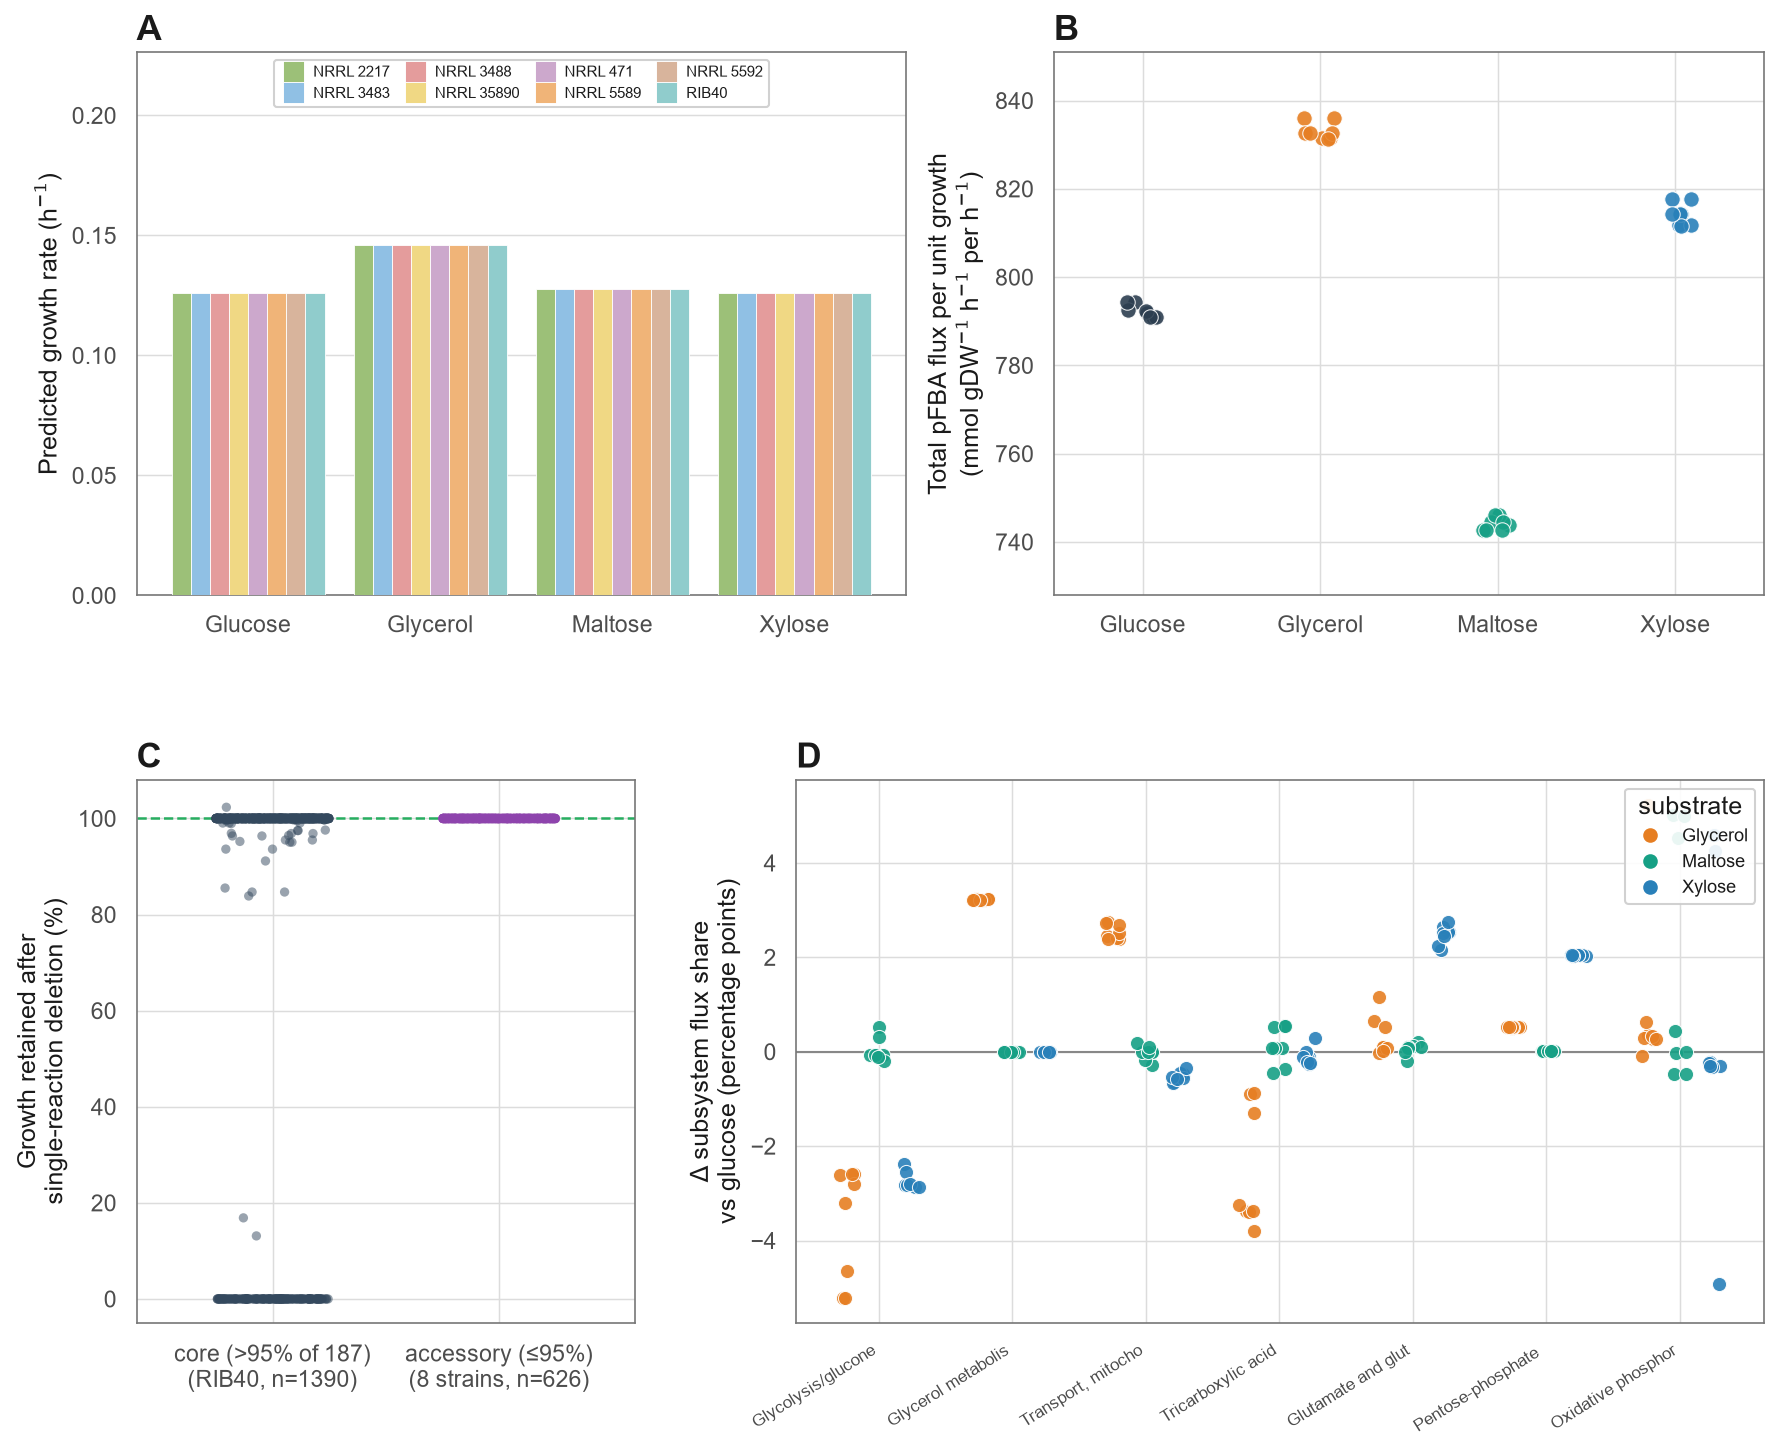

In [ ]:
display(Image(OUT+'fig_mechanistic_manuscript.png'))

### 9b. Supplementary figure — all-reaction loopless-FVA range heatmap

The loopless flux range of every flux-carrying reaction (827 reactions with a non-zero range), grouped by subsystem and shown on a log scale: the eight strains are visually indistinguishable for the large majority of reactions, with the few differences concentrated in fatty-acid biosynthesis and mitochondrial transport — reactions that are inactive at the parsimonious optimum, which is why the growth and pFBA predictions remain near-identical across strains.

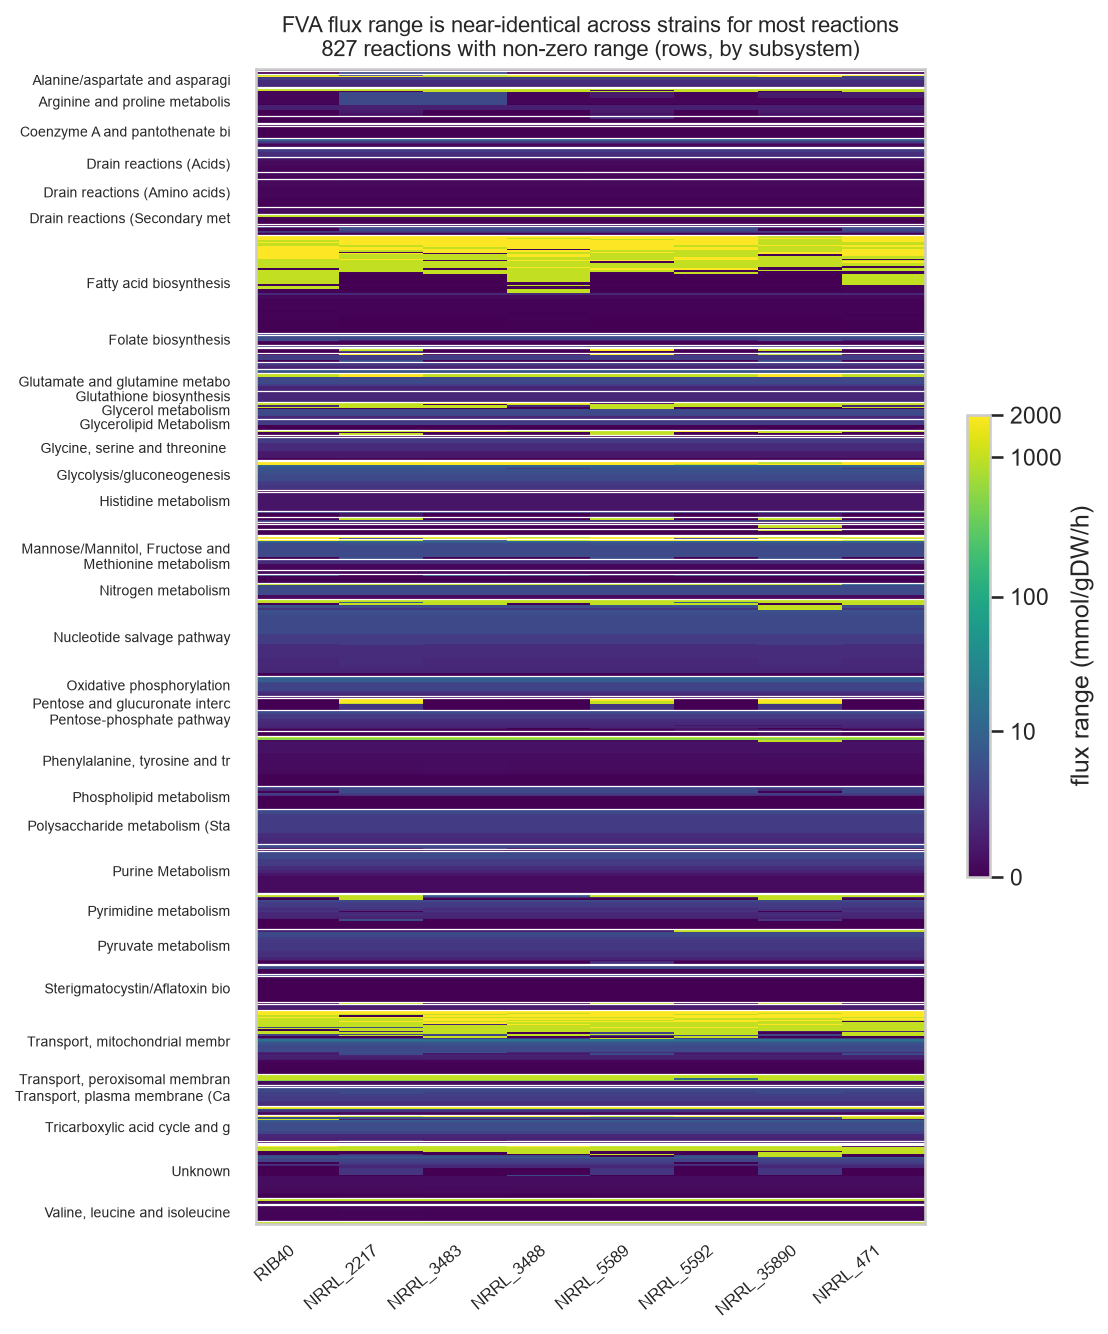

In [ ]:
display(Image(OUT+'fig_fva_allrxn_heatmap.png'))